
===== Results =====
h=1h | Winter (January) | RMSE=0.679 | Baseline=0.786 | Improvement=13.6%
h=1h | Summer (July) | RMSE=0.701 | Baseline=0.960 | Improvement=27.0%
h=3h | Winter (January) | RMSE=1.685 | Baseline=1.879 | Improvement=10.3%
h=3h | Summer (July) | RMSE=1.319 | Baseline=2.367 | Improvement=44.3%
h=6h | Winter (January) | RMSE=2.748 | Baseline=3.127 | Improvement=12.1%
h=6h | Summer (July) | RMSE=1.804 | Baseline=4.089 | Improvement=55.9%
h=12h | Winter (January) | RMSE=3.807 | Baseline=4.754 | Improvement=19.9%
h=12h | Summer (July) | RMSE=2.255 | Baseline=5.700 | Improvement=60.4%
h=24h | Winter (January) | RMSE=4.879 | Baseline=6.223 | Improvement=21.6%
h=24h | Summer (July) | RMSE=2.501 | Baseline=3.217 | Improvement=22.3%
h=48h | Winter (January) | RMSE=5.838 | Baseline=7.407 | Improvement=21.2%
h=48h | Summer (July) | RMSE=2.978 | Baseline=4.198 | Improvement=29.1%


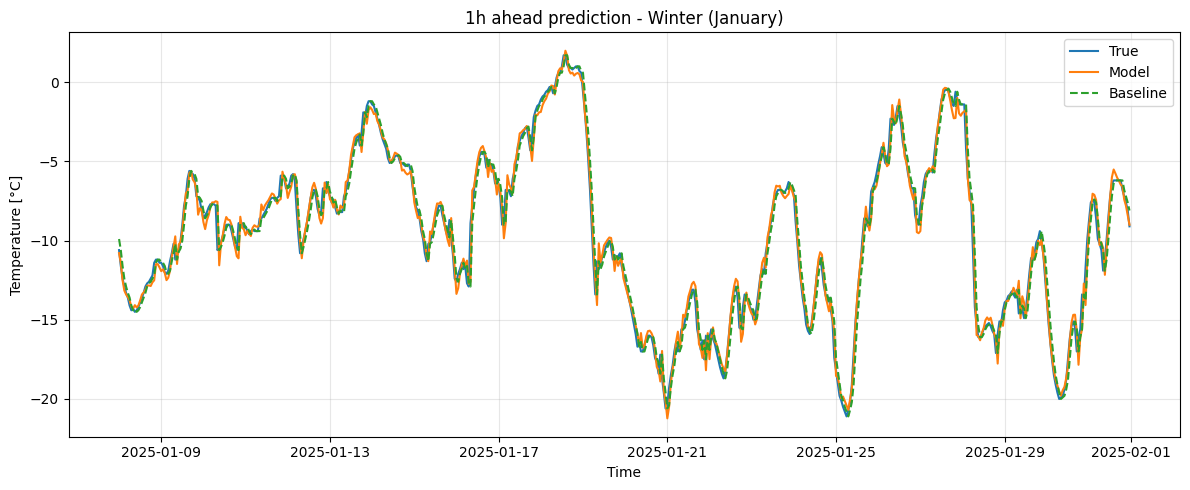

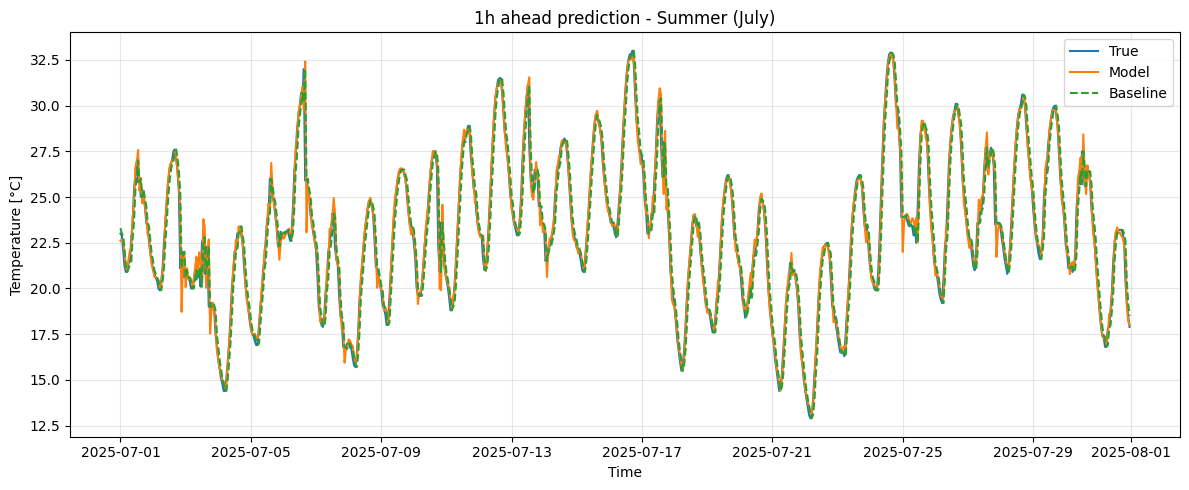

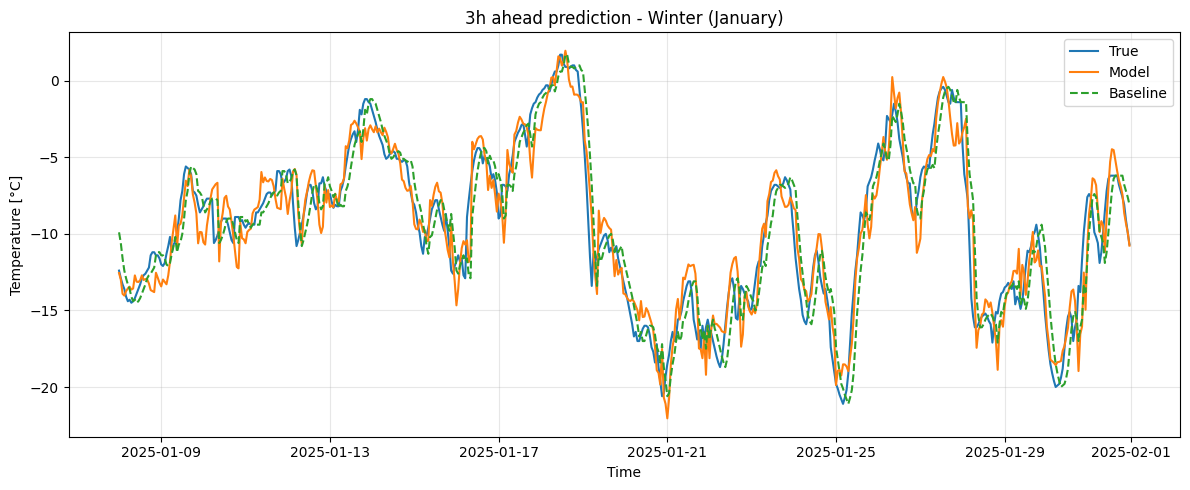

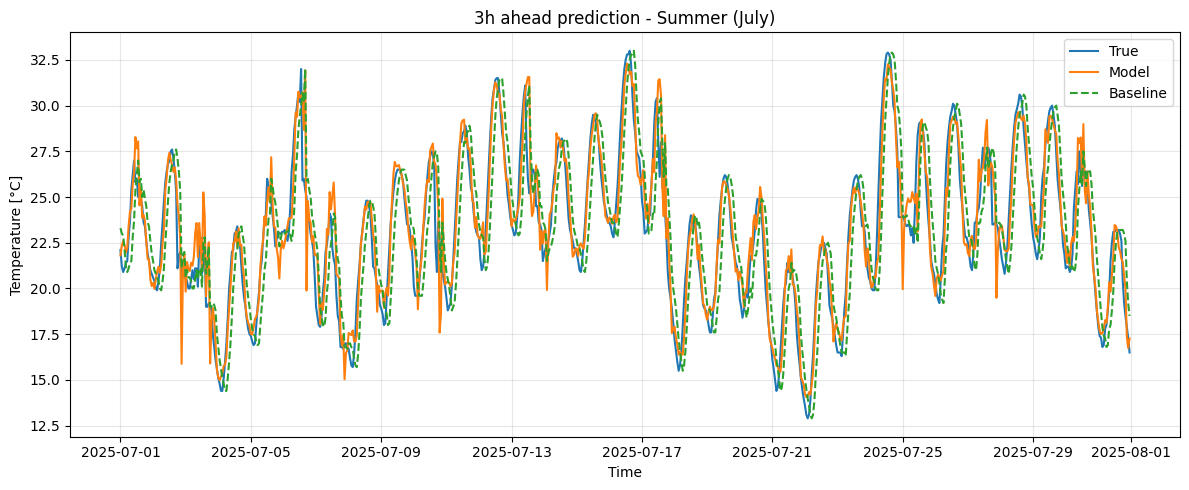

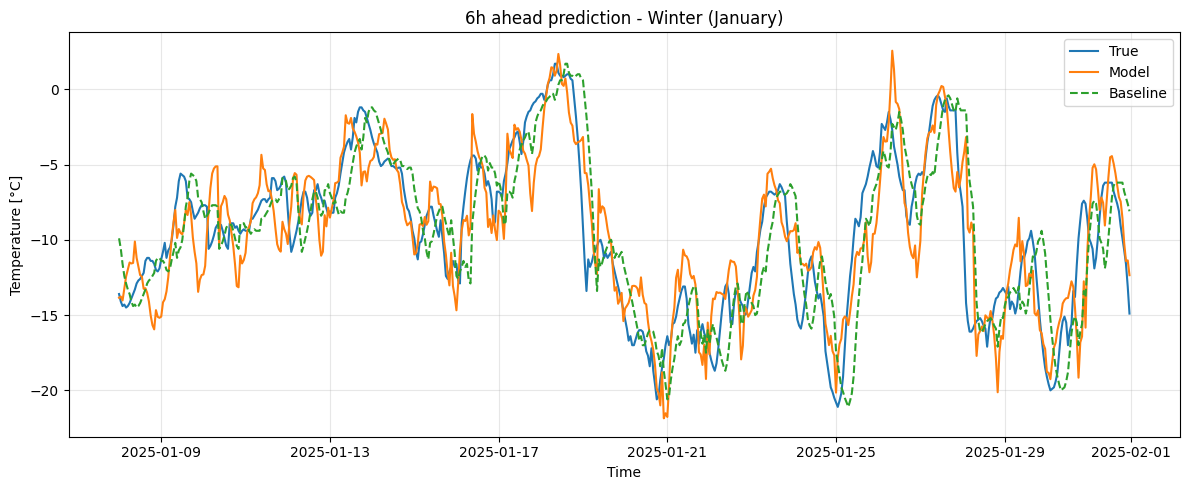

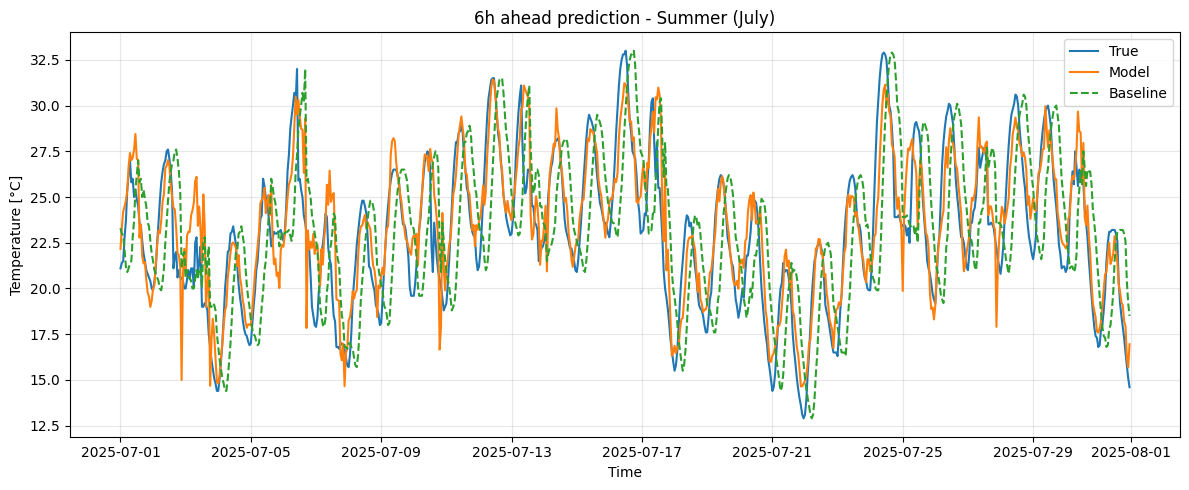

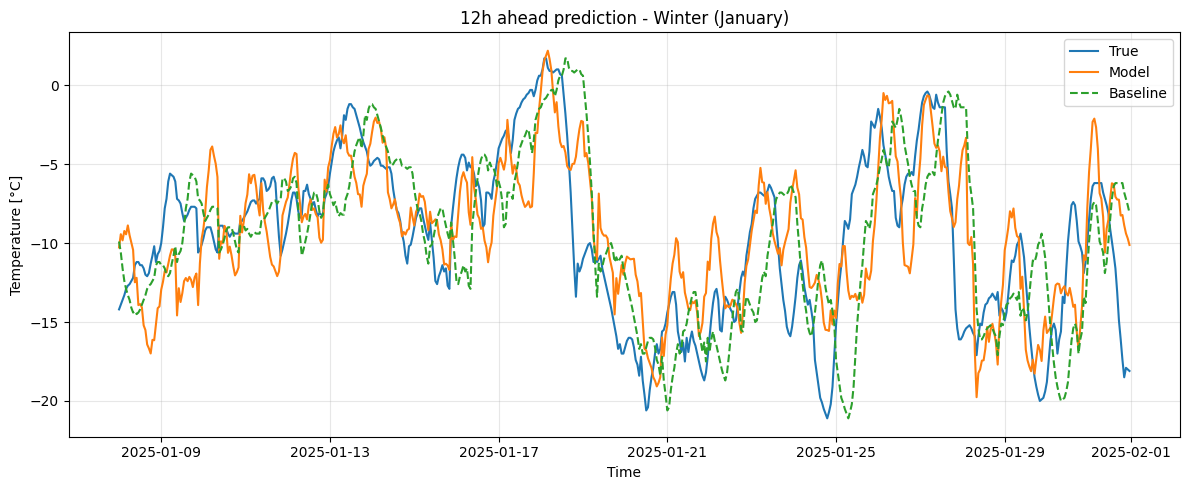

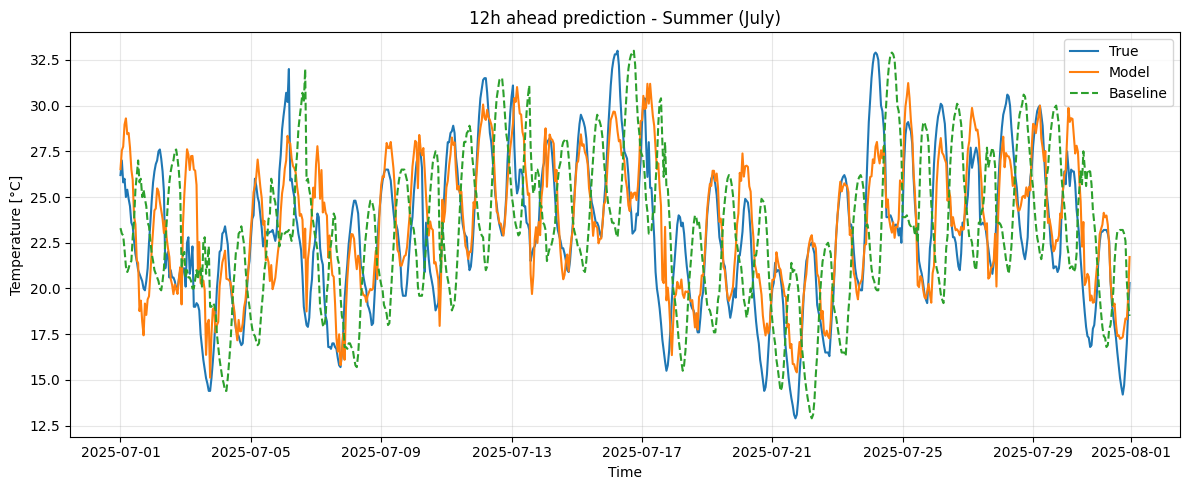

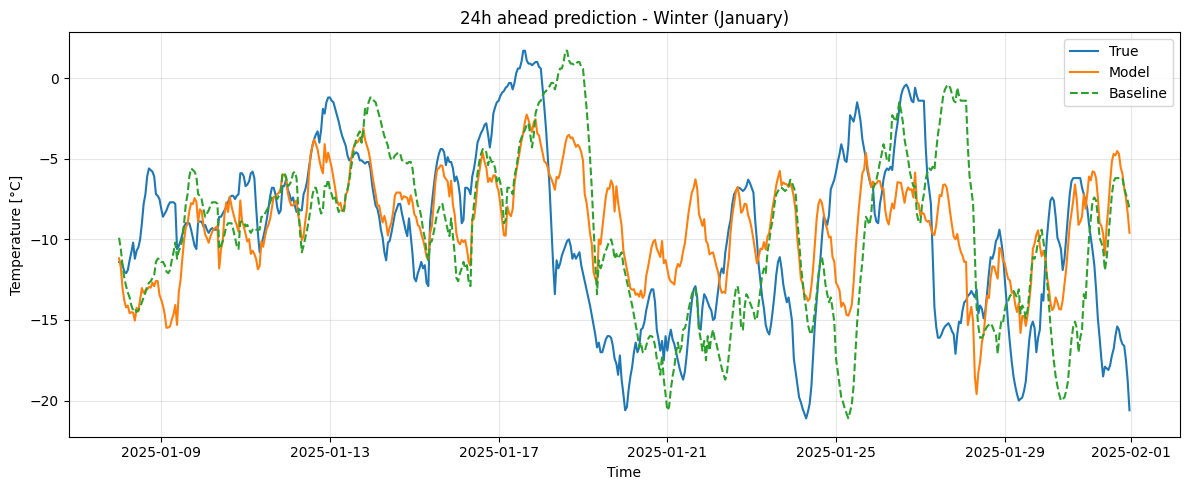

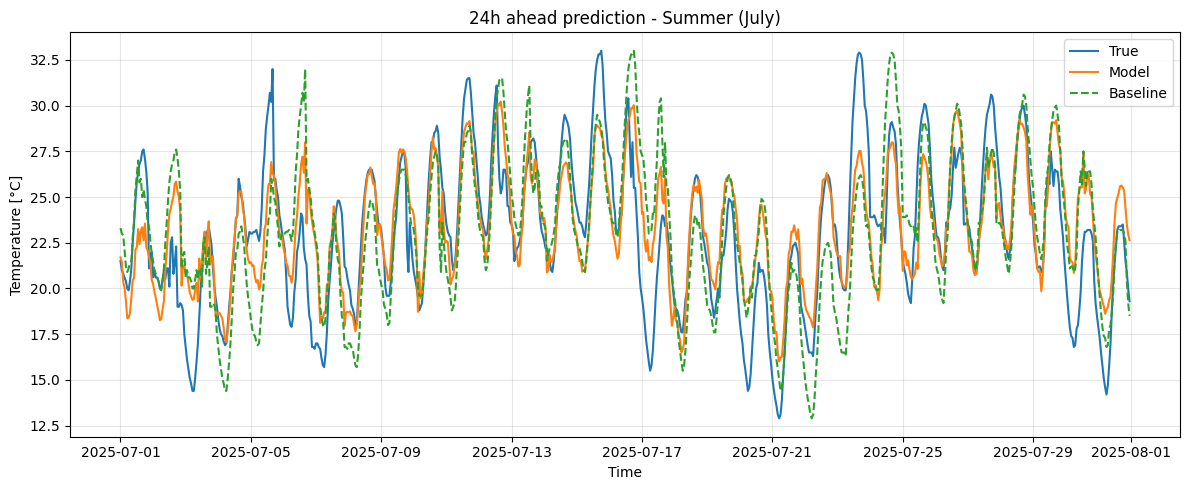

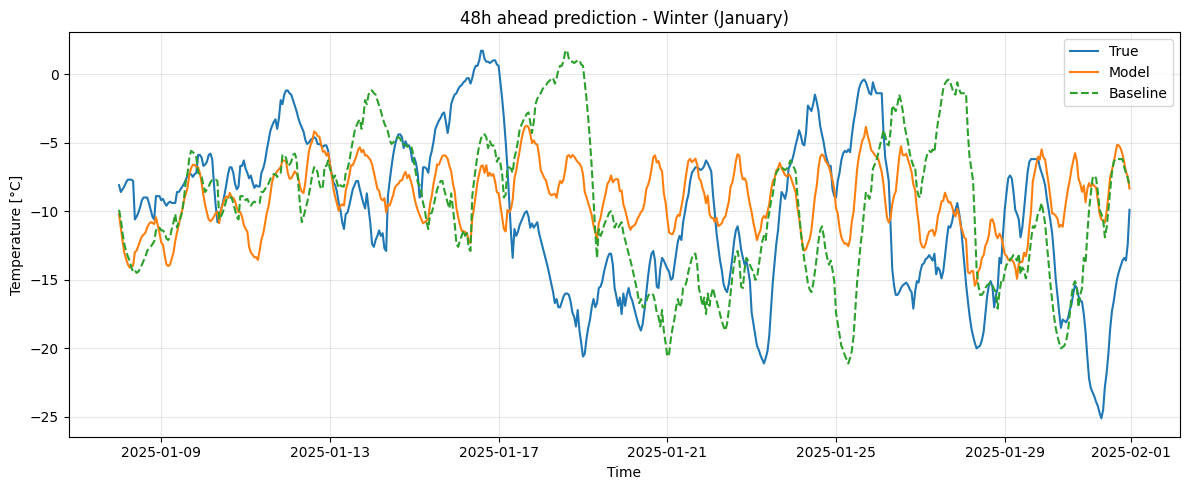

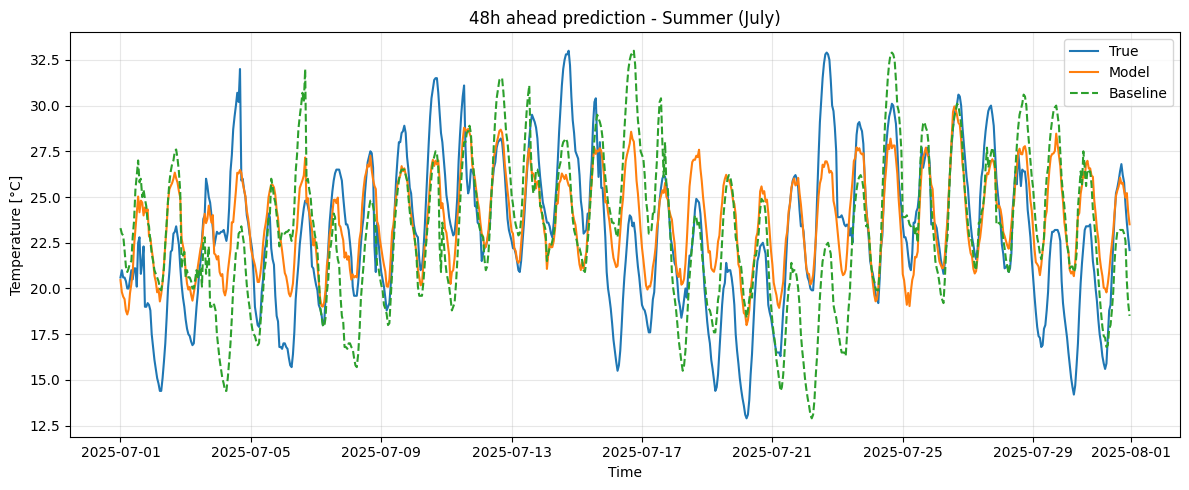

In [1]:
# ================================
# MECH 309 - Part 1
# Multi-horizon temperature prediction
# Horizons: 1h, 3h, 6h, 12h, 24h, 48h
# Seasonal validation: winter + summer
# ================================

!pip -q install numpy pandas matplotlib requests

from __future__ import annotations
import math
from dataclasses import dataclass
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


# -------------------------------
# Location definition
# -------------------------------
@dataclass(frozen=True)
class Location:
    name: str
    lat: float
    lon: float
    timezone: str


MONTREAL = Location(
    name="Montreal, QC",
    lat=45.5017,
    lon=-73.5673,
    timezone="America/Montreal",
)


# -------------------------------
# Fetch hourly weather data
# -------------------------------
def fetch_open_meteo_hourly(start_date, end_date, location=MONTREAL):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": location.lat,
        "longitude": location.lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join([
            "temperature_2m",
            "wind_speed_10m",
            "relative_humidity_2m",
            "surface_pressure",
            "cloud_cover"
        ]),
        "timezone": location.timezone,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    hourly = payload["hourly"]
    idx = pd.to_datetime(hourly["time"])

    df = pd.DataFrame(index=idx)
    df["T"] = hourly["temperature_2m"]
    df["W"] = hourly["wind_speed_10m"]
    df["RH"] = hourly["relative_humidity_2m"]
    df["P"] = hourly["surface_pressure"]
    df["Cloud"] = hourly["cloud_cover"]

    df.index.name = "time_local"
    return df


# -------------------------------
# Preprocessing + feature construction
# -------------------------------
def preprocess(df):

    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h", tz=df.index.tz)
    df = df.reindex(full_idx)

    df = df.interpolate(limit=6).ffill().bfill()

    hour = df.index.hour.to_numpy()
    omega_day = 2 * math.pi / 24
    df["sin_day"] = np.sin(omega_day * hour)
    df["cos_day"] = np.cos(omega_day * hour)

    doy = df.index.dayofyear.to_numpy()
    omega_year = 2 * math.pi / 365.25
    df["sin_year"] = np.sin(omega_year * doy)
    df["cos_year"] = np.cos(omega_year * doy)

    return df


# -------------------------------
# Lagged predictors
# -------------------------------
def add_lags(df, col, lags):
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)
    return df


# -------------------------------
# Error metrics
# -------------------------------
def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat)**2))

def mae(y, yhat):
    return np.mean(np.abs(y - yhat))


# -------------------------------
# Seasonal split
# -------------------------------
def seasonal_split(df, year, month):
    val_mask = (df.index.year == year) & (df.index.month == month)
    val_df = df.loc[val_mask].copy()
    train_df = df.loc[~val_mask].copy()
    return train_df, val_df


# -------------------------------
# Model
# -------------------------------
def run_model_for_month(df_base, h, feature_cols, year, month, month_name):

    df = df_base.copy()
    df["T_target"] = df["T"].shift(-h)
    df = df.dropna().copy()

    train_df, val_df = seasonal_split(df, year, month)

    X_train = train_df[feature_cols].to_numpy()
    y_train = train_df["T_target"].to_numpy()

    X_val = val_df[feature_cols].to_numpy()
    y_val = val_df["T_target"].to_numpy()

    X_train = np.column_stack([np.ones(len(X_train)), X_train])
    X_val = np.column_stack([np.ones(len(X_val)), X_val])

    theta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

    yhat_train = X_train @ theta
    yhat_val = X_val @ theta

    baseline = val_df["T"].to_numpy()

    return {
        "h": h,
        "month_name": month_name,
        "train_rmse": rmse(y_train, yhat_train),
        "val_rmse": rmse(y_val, yhat_val),
        "val_mae": mae(y_val, yhat_val),
        "baseline_rmse": rmse(y_val, baseline),
        "val_index": val_df.index,
        "y_val": y_val,
        "yhat": yhat_val,
        "baseline": baseline
    }


# ================================
# MAIN
# ================================

# 1) Data
df_raw = fetch_open_meteo_hourly("2025-01-01", "2025-12-31")

# 2) Preprocess
df = preprocess(df_raw)

# 3) Add lags (IMPORTANT for 48h)
df = add_lags(df, "T", [1,2,3,6,12,24,48,72,168])
df = add_lags(df, "W", [1,6,12,24,48])
df = add_lags(df, "RH", [1,6,24])
df = add_lags(df, "P", [1,6,24])
df = add_lags(df, "Cloud", [1,6,24])

# 4) Features
feature_cols = [
    "T","W","RH","P","Cloud",
    "sin_day","cos_day",
    "sin_year","cos_year",

    "T_lag1","T_lag2","T_lag3","T_lag6","T_lag12","T_lag24","T_lag48","T_lag72","T_lag168",
    "W_lag1","W_lag6","W_lag12","W_lag24","W_lag48",
    "RH_lag1","RH_lag6","RH_lag24",
    "P_lag1","P_lag6","P_lag24",
    "Cloud_lag1","Cloud_lag6","Cloud_lag24"
]

# 5) Horizons (UPDATED)
horizons = [1, 3, 6, 12, 24, 48]

# 6) Validation months
validation_months = [
    (2025, 1, "Winter (January)"),
    (2025, 7, "Summer (July)")
]

results = []

# 7) Run models
for h in horizons:
    for year, month, name in validation_months:
        res = run_model_for_month(df, h, feature_cols, year, month, name)
        results.append(res)

# -------------------------------
# 8) Print results
# -------------------------------
print("\n===== Results =====")
for r in results:
    improvement = 100*(r["baseline_rmse"] - r["val_rmse"]) / r["baseline_rmse"]
    print(f"h={r['h']}h | {r['month_name']} | RMSE={r['val_rmse']:.3f} | Baseline={r['baseline_rmse']:.3f} | Improvement={improvement:.1f}%")

# -------------------------------
# 9) Plot results
# -------------------------------
for r in results:
    plt.figure(figsize=(12,5))
    plt.plot(r["val_index"], r["y_val"], label="True")
    plt.plot(r["val_index"], r["yhat"], label="Model")
    plt.plot(r["val_index"], r["baseline"], "--", label="Baseline")
    plt.title(f"{r['h']}h ahead prediction - {r['month_name']}")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()